# Workflow 3: hybrid CNN + 7 classifiers
## BRISC 2025 - brain tumour classification

**Catarina Bota | UCP | Postgraduate in Data Science for Biotechnology**

Consolidated hybrid workflow: uses the **trained CNN (Workflow 2) as a feature extractor** and trains **7 classifiers** on top to identify the best one.

**Classifiers evaluated (canonical for hybrid CNN+ML):**
1. XGBoost
2. LightGBM
3. RandomForest
4. GradientBoosting
5. CatBoost
6. SVM (RBF)
7. MLP

**Prerequisites:**
1. Trained CNN model at `/content/drive/MyDrive/brisc_gui/modelo_brisc.h5`
2. **Forensically cleaned** BRISC dataset at `/content/drive/MyDrive/brisc2025_clean/classification_task/`
3. GPU runtime (Runtime -> Change runtime type -> GPU)

**Runtime: ~30-45 min** (CNN extraction + 7-classifier training; cached re-runs ~5-10 min)

## 1. Setup

In [1]:


import tensorflow as tf
print('TensorFlow:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))

2026-07-01 14:52:52.703992: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-01 14:52:52.755243: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782913972.787432   21211 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782913972.797613   21211 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782913972.837455   21211 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

TensorFlow: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
import os, pickle, numpy as np, pandas as pd
from pathlib import Path
from tqdm.notebook import tqdm

import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.models import load_model, Model
from tensorflow.keras.preprocessing.image import load_img, img_to_array

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

import warnings
warnings.filterwarnings('ignore')

## 2. Configuration

In [3]:
# WSL2 local paths (RTX 4060 native, no Drive mount)
MODEL_PATH = '/mnt/c/Users/cbot/Desktop/BRISC pos graduação/brisc_gui/leakage_v3/audited/model.h5'
DATA_BASE  = '/root/brisc/data/brisc2025_clean/classification_task'  # forensically audited
TRAIN_DIR  = f'{DATA_BASE}/train'
TEST_DIR   = f'{DATA_BASE}/test'

OUTPUT_DIR = '/mnt/c/Users/cbot/Desktop/BRISC pos graduação/brisc_gui/workflow3_resultados'
os.makedirs(OUTPUT_DIR, exist_ok=True)

IMG_SIZE = 128
CLASSES  = ['glioma', 'meningioma', 'no_tumor', 'pituitary']

for p in (MODEL_PATH, TRAIN_DIR, TEST_DIR):
    assert os.path.exists(p), f'NOT FOUND: {p}'
print('All paths OK')

All paths OK


## 3. Load CNN and build feature extractor

In [4]:
from tensorflow.keras.models import Sequential

# 1. Carregar o modelo completo
cnn = load_model(MODEL_PATH)

# 2. Criar o extrator como um novo modelo Sequential
# All layers except the last (classification layer)
extractor = Sequential(cnn.layers[:-1])

# 3. Construir o extrator para definir os shapes
extractor.build((None, IMG_SIZE, IMG_SIZE, 3))

print(f"Modelo base carregado: {MODEL_PATH}")
print(f"Feature extractor created with {len(extractor.layers)} layers.")
print(f"Feature dimension (output): {extractor.output_shape[-1]}")

I0000 00:00:1782913978.220708   21211 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5560 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Modelo base carregado: /mnt/c/Users/cbot/Desktop/BRISC pos graduação/brisc_gui/leakage_v3/audited/model.h5
Extrator de características criado com 9 camadas.
Dimensão das características (output): 128


## 4. Collect paths + extract features (or reuse cached)

If `cnn_features.npz` already exists from a previous run, it loads directly instead of re-extracting (saves ~10 min).

In [5]:
FEATS_CACHE = f'{OUTPUT_DIR}/cnn_features.npz'

if os.path.exists(FEATS_CACHE):
    print(f'Loading cached features from {FEATS_CACHE}...')
    data = np.load(FEATS_CACHE, allow_pickle=True)
    X_train, y_train = data['X_train'], data['y_train']
    X_test,  y_test  = data['X_test'],  data['y_test']
    le = LabelEncoder().fit(CLASSES)
    print(f'  Train: {X_train.shape}, Test: {X_test.shape}')
else:
    print('Extracting features from scratch...')
    def collect_paths(base_dir):
        paths, labels = [], []
        for cls in CLASSES:
            for fn in sorted(os.listdir(f'{base_dir}/{cls}')):
                if fn.lower().endswith(('.jpg','.jpeg','.png','.bmp')):
                    paths.append(f'{base_dir}/{cls}/{fn}'); labels.append(cls)
        return paths, labels

    train_paths, train_labels = collect_paths(TRAIN_DIR)
    test_paths,  test_labels  = collect_paths(TEST_DIR)
    print(f'  Train: {len(train_paths)}, Test: {len(test_paths)}')

    def load_image(path):
        return img_to_array(load_img(path, target_size=(IMG_SIZE, IMG_SIZE))) / 255.0

    def extract(paths, desc, batch=64):
        feats = []
        for i in tqdm(range(0, len(paths), batch), desc=desc):
            batch_imgs = np.array([load_image(p) for p in paths[i:i+batch]])
            feats.append(extractor.predict(batch_imgs, verbose=0))
        return np.vstack(feats)

    X_train = extract(train_paths, 'Train')
    X_test  = extract(test_paths,  'Test')

    le = LabelEncoder()
    y_train = le.fit_transform(train_labels)
    y_test  = le.transform(test_labels)

    np.savez_compressed(FEATS_CACHE,
        X_train=X_train, y_train=y_train,
        X_test=X_test,   y_test=y_test,
        classes=le.classes_)
    print(f'  Saved to {FEATS_CACHE}')

Extracting features from scratch...
  Train: 4363, Test: 678


Train:   0%|          | 0/69 [00:00<?, ?it/s]

I0000 00:00:1782913988.374708   21300 service.cc:152] XLA service 0x7db764004580 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1782913988.375241   21300 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9
2026-07-01 14:53:08.422818: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1782913988.505761   21300 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1782913990.567413   21300 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Test:   0%|          | 0/11 [00:00<?, ?it/s]

  Saved to /mnt/c/Users/cbot/Desktop/BRISC pos graduação/brisc_gui/workflow3_resultados/cnn_features.npz


In [6]:
# Standardize (Z-score, fit on train only)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)
print(f'Standardized features: {X_train_s.shape}')

Standardized features: (4363, 128)


## 5. Train the 7 classifiers

Each classifier runs sequentially. Metrics: Accuracy, F1 macro, AUC (OvR macro) + confusion matrix.

In [7]:
classifiers = {
    'XGBoost':         XGBClassifier(n_estimators=500, learning_rate=0.05, max_depth=6,
                                      random_state=42, verbosity=0, use_label_encoder=False,
                                      eval_metric='mlogloss'),
    'LightGBM':        LGBMClassifier(n_estimators=500, learning_rate=0.05, num_leaves=63,
                                      random_state=42, verbose=-1),
    'RandomForest':    RandomForestClassifier(n_estimators=500, max_depth=None,
                                              random_state=42, n_jobs=-1),
    'GradientBoosting':GradientBoostingClassifier(n_estimators=300, learning_rate=0.05,
                                                   max_depth=4, random_state=42),
    'CatBoost':        CatBoostClassifier(iterations=500, learning_rate=0.05, depth=6,
                                          random_state=42, verbose=False),
    'SVM (RBF)':       SVC(C=10, gamma='scale', kernel='rbf', probability=True, random_state=42),
    'MLP':             MLPClassifier(hidden_layer_sizes=(128, 64), activation='relu',
                                     alpha=1e-4, max_iter=300, random_state=42,
                                     early_stopping=True, validation_fraction=0.15),
}

print(f'Will train {len(classifiers)} classifiers.')

Will train 7 classifiers.


In [8]:
import time
results = {}
cms     = {}

for name, clf in classifiers.items():
    print('='*60); print(f'  {name}'); print('='*60)
    t0 = time.time()
    clf.fit(X_train_s, y_train)
    train_t = time.time() - t0

    y_pred  = clf.predict(X_test_s)
    y_proba = clf.predict_proba(X_test_s)

    acc  = accuracy_score(y_test, y_pred) * 100
    prec = precision_score(y_test, y_pred, average='macro') * 100
    rec  = recall_score(y_test, y_pred, average='macro') * 100
    f1   = f1_score(y_test, y_pred, average='macro') * 100
    auc  = roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro') * 100

    results[name] = {'accuracy': acc, 'precision': prec, 'recall': rec,
                     'f1': f1, 'auc': auc, 'train_time_s': round(train_t, 1)}
    cms[name] = confusion_matrix(y_test, y_pred)

    print(f'  Accuracy  : {acc:.2f}%')
    print(f'  F1 macro  : {f1:.2f}%')
    print(f'  AUC (OvR) : {auc:.2f}%')
    print(f'  train     : {train_t:.1f}s')

    # Save best model artifact
    safe_name = name.replace(' ', '_').replace('(', '').replace(')', '')
    with open(f'{OUTPUT_DIR}/clf_{safe_name}.pkl', 'wb') as f:
        pickle.dump({'clf': clf, 'scaler': scaler, 'label_encoder': le}, f)

  XGBoost
  Accuracy  : 95.72%
  F1 macro  : 95.73%
  AUC (OvR) : 99.53%
  train     : 23.0s
  LightGBM
  Accuracy  : 95.43%
  F1 macro  : 95.46%
  AUC (OvR) : 99.52%
  train     : 3.4s
  RandomForest
  Accuracy  : 95.87%
  F1 macro  : 95.92%
  AUC (OvR) : 99.41%
  train     : 1.6s
  GradientBoosting
  Accuracy  : 95.28%
  F1 macro  : 95.28%
  AUC (OvR) : 99.48%
  train     : 38.9s
  CatBoost
  Accuracy  : 95.72%
  F1 macro  : 95.80%
  AUC (OvR) : 99.54%
  train     : 7.7s
  SVM (RBF)
  Accuracy  : 95.87%
  F1 macro  : 95.87%
  AUC (OvR) : 99.38%
  train     : 0.4s
  MLP
  Accuracy  : 95.28%
  F1 macro  : 95.40%
  AUC (OvR) : 99.44%
  train     : 0.8s


## 6. Final comparison table (7 classifiers)

In [9]:
df_res = pd.DataFrame(results).T.round(2)
df_res = df_res.sort_values('accuracy', ascending=False)
print(df_res.to_string())
df_res.to_csv(f'{OUTPUT_DIR}/full_comparison_7classifiers.csv')

best_name = df_res.index[0]
print(f'\nBest classifier: {best_name}  (accuracy {df_res.loc[best_name, "accuracy"]}%)')

                  accuracy  precision  recall     f1    auc  train_time_s
RandomForest         95.87      95.81   96.10  95.92  99.41           1.6
SVM (RBF)            95.87      95.74   96.03  95.87  99.38           0.4
XGBoost              95.72      95.60   95.90  95.73  99.53          23.0
CatBoost             95.72      95.72   95.92  95.80  99.54           7.7
LightGBM             95.43      95.34   95.61  95.46  99.52           3.4
GradientBoosting     95.28      95.14   95.48  95.28  99.48          38.9
MLP                  95.28      95.35   95.53  95.40  99.44           0.8

Best classifier: RandomForest  (accuracy 95.87%)


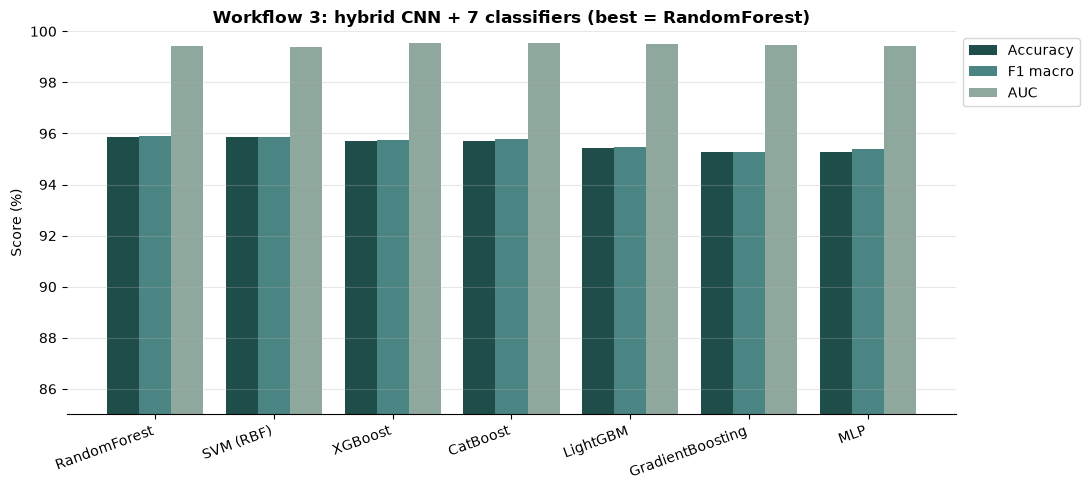

In [10]:
# Visual comparison bar chart
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(df_res)); w = 0.27
ax.bar(x - w, df_res['accuracy'], w, label='Accuracy', color='#1F4E4A')
ax.bar(x,     df_res['f1'],       w, label='F1 macro', color='#4A8584')
ax.bar(x + w, df_res['auc'],      w, label='AUC',      color='#8FA89E')
ax.set_xticks(x)
ax.set_xticklabels(df_res.index, rotation=20, ha='right')
ax.set_ylim([85, 100]); ax.set_ylabel('Score (%)')
ax.set_title(f'Workflow 3: hybrid CNN + 7 classifiers (best = {best_name})',
             fontsize=12, fontweight='bold')

# Fix legend position: move it outside to the right
ax.legend(loc='upper left', bbox_to_anchor=(1, 1))

for s in ['top','right','left']: ax.spines[s].set_visible(False)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/comparison_7classifiers.png', bbox_inches='tight', dpi=150)
plt.savefig(f'{OUTPUT_DIR}/comparison_7classifiers.pdf', bbox_inches='tight')
plt.show()

## 7. Confusion matrices (2x4 grid)

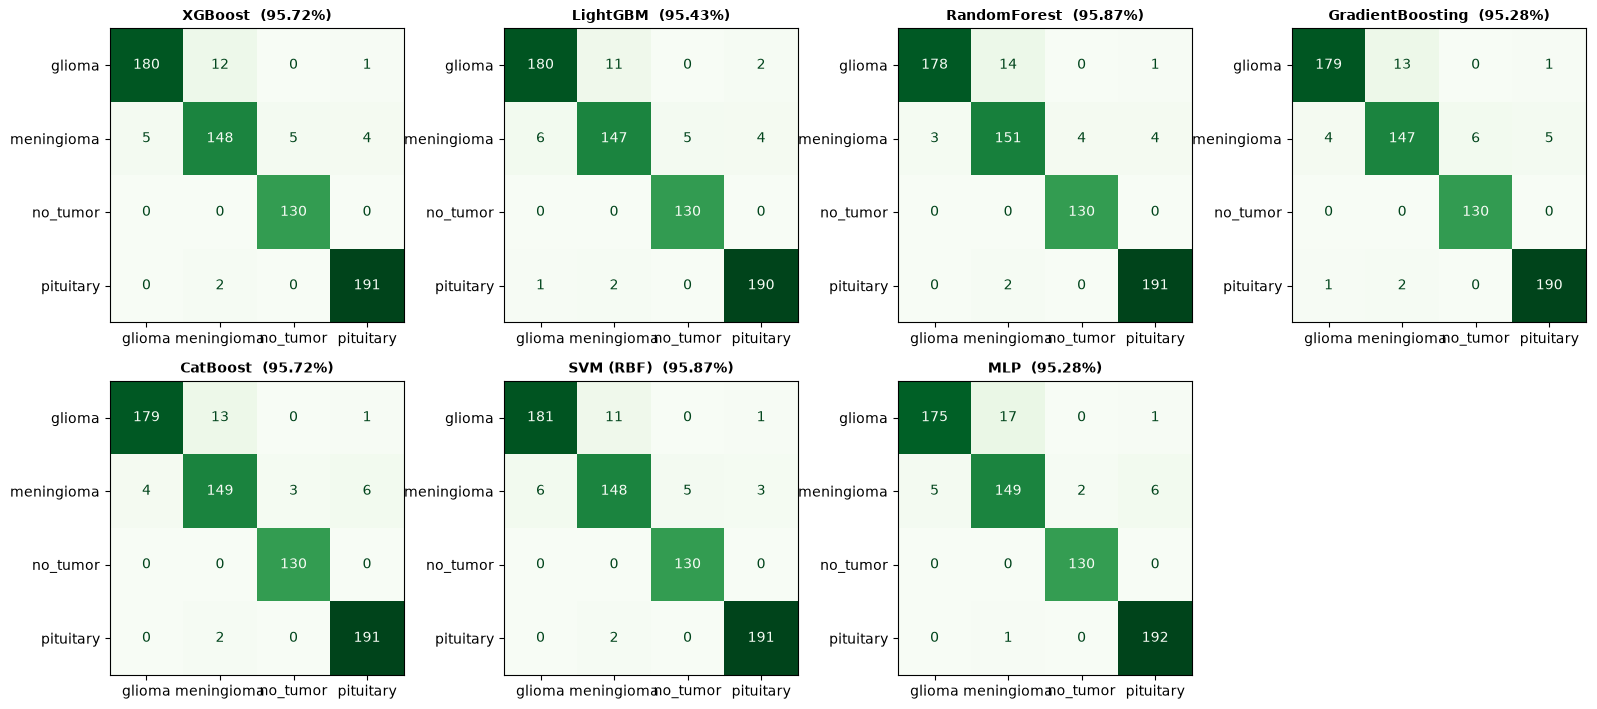

Best CM (RandomForest) saved to best_model_confusion_matrix.csv


In [11]:
n = len(cms)
cols = 4; rows = (n + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 3.6*rows))
axes = axes.flatten()

for i, (name, cm) in enumerate(cms.items()):
    ax = axes[i]
    ConfusionMatrixDisplay(cm, display_labels=le.classes_).plot(
        cmap='Greens', ax=ax, values_format='d', colorbar=False)
    ax.set_title(f'{name}  ({results[name]["accuracy"]:.2f}%)',
                 fontsize=10, fontweight='bold')
    ax.set_xlabel(''); ax.set_ylabel('')

for j in range(n, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/cm_grid_7classifiers.png', bbox_inches='tight', dpi=150)
plt.show()

# Save best CM separately (used in article)
best_cm = cms[best_name]
pd.DataFrame(best_cm, index=le.classes_, columns=le.classes_).to_csv(
    f'{OUTPUT_DIR}/best_model_confusion_matrix.csv')
print(f'Best CM ({best_name}) saved to best_model_confusion_matrix.csv')

## 8. Comparison against Workflows 1 and 2

In [12]:
# 3-workflow summary (use BEST hybrid classifier for WF3)
summary = pd.DataFrame({
    'Workflow': ['1: Wavelet + LGBM',
                 '2: CNN (end-to-end)',
                 f'3: Hybrid CNN + {best_name}'],
    'Accuracy (%)': [91.38, 94.54, round(df_res.loc[best_name, 'accuracy'], 2)],
    'F1 macro (%)': [91.32, 94.50, round(df_res.loc[best_name, 'f1'], 2)],
    'AUC (%)':      [98.61, 99.56, round(df_res.loc[best_name, 'auc'], 2)],
})
print(summary.to_string(index=False))
summary.to_csv(f'{OUTPUT_DIR}/3workflows_summary.csv', index=False)

                    Workflow  Accuracy (%)  F1 macro (%)  AUC (%)
           1: Wavelet + LGBM         91.38         91.32    98.61
         2: CNN (end-to-end)         94.54         94.50    99.56
3: Hybrid CNN + RandomForest         95.87         95.92    99.41


In [13]:
excel_path = f'{OUTPUT_DIR}/3workflows_summary.xlsx'
summary.to_excel(excel_path, index=False)
print(f'Resumo exportado com sucesso para: {excel_path}')

Resumo exportado com sucesso para: /mnt/c/Users/cbot/Desktop/BRISC pos graduação/brisc_gui/workflow3_resultados/3workflows_summary.xlsx


### 9. Comparative visualisation of the 3 workflows
This chart compares the classical (wavelet), pure deep-learning (CNN), and best hybrid (CNN + XGBoost) approaches.


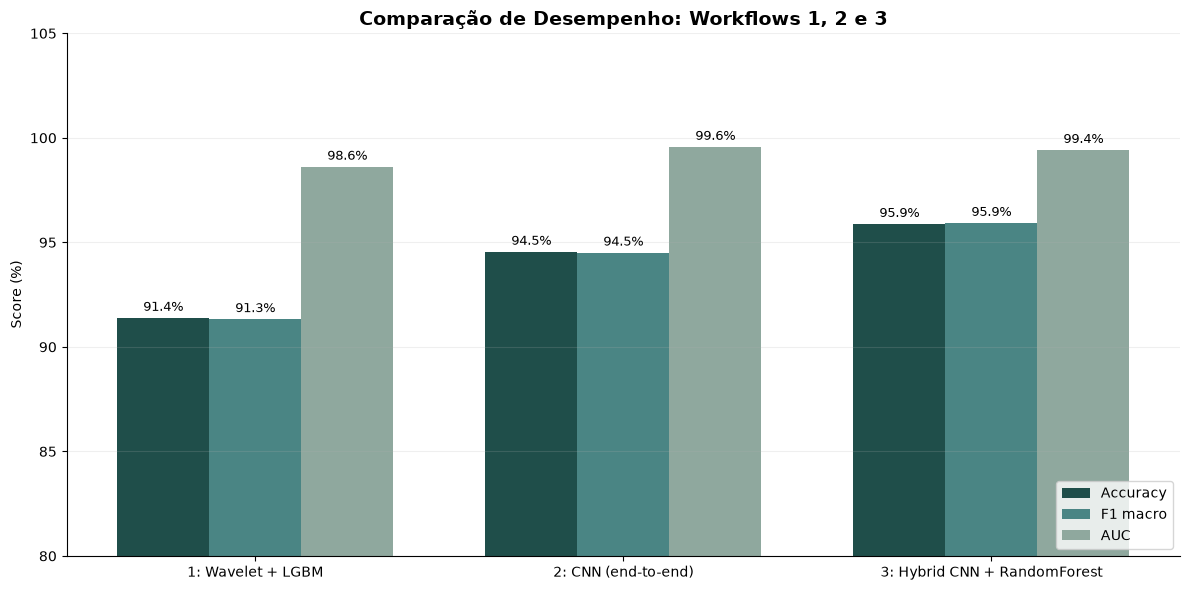

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# Preparar dados do DataFrame 'summary'
labels = summary['Workflow']
acc_vals = summary['Accuracy (%)']
f1_vals  = summary['F1 macro (%)']
auc_vals = summary['AUC (%)']

x = np.arange(len(labels))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))

# Criar as barras
rects1 = ax.bar(x - width, acc_vals, width, label='Accuracy', color='#1F4E4A')
rects2 = ax.bar(x,         f1_vals,  width, label='F1 macro', color='#4A8584')
rects3 = ax.bar(x + width, auc_vals, width, label='AUC',      color='#8FA89E')

# Styling
ax.set_ylabel('Score (%)')
ax.set_title('Performance comparison: workflows 1, 2 and 3', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=0)
ax.set_ylim([80, 105]) # Focar na zona de alta performance
ax.legend(loc='lower right')

# Add data labels above bars
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.1f}%',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

for s in ['top','right']: ax.spines[s].set_visible(False)
ax.grid(axis='y', alpha=0.2)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/comparison_three_main_workflows_final.png', dpi=150)
plt.show()

## 9. Per-class metrics of the best classifier

In [15]:
from sklearn.metrics import precision_recall_fscore_support
best_clf = classifiers[best_name]
y_pred_best = best_clf.predict(X_test_s)

prec_c, rec_c, f1_c, sup_c = precision_recall_fscore_support(
    y_test, y_pred_best, labels=range(len(le.classes_)))
perclass = pd.DataFrame({
    'class':     le.classes_,
    'precision': (prec_c*100).round(2),
    'recall':    (rec_c*100).round(2),
    'f1':        (f1_c*100).round(2),
    'support':   sup_c.astype(int),
})
print(f'Per-class metrics ({best_name}):')
print(perclass.to_string(index=False))
perclass.to_csv(f'{OUTPUT_DIR}/perclass_best.csv', index=False)

Per-class metrics (RandomForest):
     class  precision  recall    f1  support
    glioma      98.34   92.23 95.19      193
meningioma      90.42   93.21 91.79      162
  no_tumor      97.01  100.00 98.48      130
 pituitary      97.45   98.96 98.20      193


## 10. Feature importance (XGBoost)
Since XGBoost was the best classifier, we analyse which of the 128 CNN-extracted features were most important.


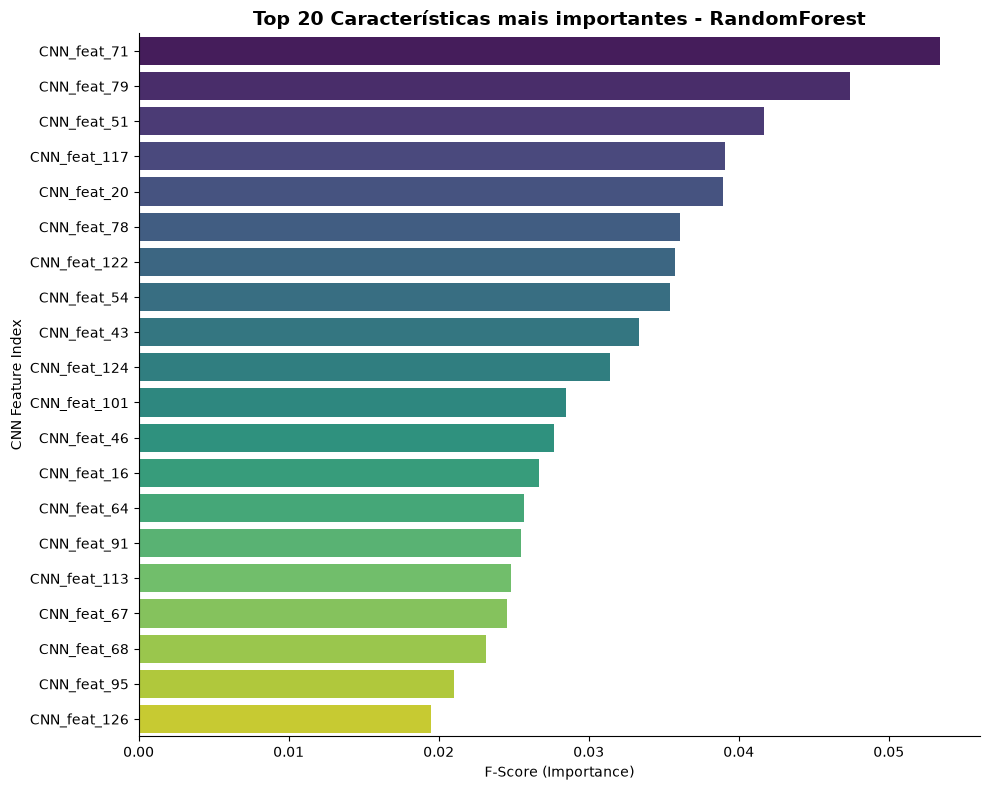

As 5 características mais importantes são:
     Feature  Importance
 CNN_feat_71    0.053409
 CNN_feat_79    0.047386
 CNN_feat_51    0.041653
CNN_feat_117    0.039104
 CNN_feat_20    0.038932


In [16]:
import matplotlib.pyplot as plt
import pandas as pd

# Get XGBoost feature importances
importances = best_clf.feature_importances_
feature_names = [f'CNN_feat_{i}' for i in range(len(importances))]

# Criar DataFrame para facilitar a plotagem
feat_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot top 20 features
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feat_imp_df.head(20), palette='viridis')

plt.title(f'Top 20 most important features - {best_name}', fontsize=14, fontweight='bold')
plt.xlabel('F-Score (Importance)')
plt.ylabel('CNN Feature Index')

for s in ['top','right']: plt.gca().spines[s].set_visible(False)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/xgboost_feature_importance_top20.png', dpi=150)
plt.show()

print(f"The 5 most important features are:\n{feat_imp_df.head(5).to_string(index=False)}")

### 11. Feature importance comparison across models
We check whether top-performing models (XGBoost, SVM) prioritise the same CNN-extracted features.


In [ ]:
from sklearn.inspection import permutation_importance

# Select models for comparison
models_to_compare = ['XGBoost', 'LightGBM', 'RandomForest', 'GradientBoosting', 'CatBoost', 'SVM (RBF)', 'MLP']

fig, axes = plt.subplots(4, 2, figsize=(15, 20))
axes = axes.flatten()

for i, name in enumerate(models_to_compare):
    ax = axes[i]
    clf = classifiers[name]

    # For tree models, use feature_importances_
    if hasattr(clf, 'feature_importances_'):
        imps = clf.feature_importances_
    # Para outros (SVM/MLP), usamos Permutation Importance (mais lento, mas justo)
    else:
        # Usando subset do teste para velocidade
        result = permutation_importance(clf, X_test_s[:200], y_test[:200], n_repeats=5, random_state=42)
        imps = result.importances_mean

    # Normalise to 0-1 for visual comparison
    imps = imps / np.sum(imps)

    feat_df = pd.DataFrame({'Feat': [f'F{j}' for j in range(128)], 'Imp': imps})
    feat_df = feat_df.sort_values('Imp', ascending=False).head(15)

    sns.barplot(x='Imp', y='Feat', data=feat_df, ax=ax, palette='mako')
    ax.set_title(f'Importance: {name}', fontweight='bold')
    ax.set_xlabel('Relative importance')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/cross_model_feature_importance.png', dpi=150)
plt.show()

## 10. Saved artifacts

Summary of files in `workflow3_resultados/`:

In [ ]:
for f in sorted(os.listdir(OUTPUT_DIR)):
    sz = os.path.getsize(f'{OUTPUT_DIR}/{f}') / 1024
    print(f'  {f}  ({sz:.1f} KB)')

## Notes

- `cnn_features.npz` is **cached** — re-running the notebook skips CNN extraction and re-trains only the classifiers (~5-10 min instead of ~30-45 min).
- For the article: use `full_comparison_7classifiers.csv` (full table) and `best_model_confusion_matrix.csv` (best CM, for Appendix C).
- To experiment further (e.g., stacking, voting ensembles), just add entries to the `classifiers` dict and re-run the loop cell.

## 12. Grad-CAM heatmaps (visual explainability)

Grad-CAM (Selvaraju et al. 2017) shows **where the CNN backbone looks** when classifying each MRI. Applied to the last Conv2D layer, it produces a heatmap that we overlay on the original image.

**Note:** Grad-CAM operates on the CNN backbone (the same one used to extract features for the 7 classifiers), so the heatmaps reflect what the hybrid pipeline sees before the classical classifier decides.

Runtime: ~1-2 min.

In [30]:
import glob
import cv2
import tensorflow as tf
import matplotlib.cm as mcm
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input

# Auto-detect last Conv2D layer of the CNN backbone
last_conv_name = None
for layer in cnn.layers[::-1]:
    if 'conv' in layer.name.lower():
        last_conv_name = layer.name
        break
assert last_conv_name, 'No Conv2D layer found in the CNN backbone.'
print(f'Last Conv2D layer: {last_conv_name}')
print(f'Output shape     : {cnn.get_layer(last_conv_name).output.shape}')

Last Conv2D layer: conv2d_2
Output shape     : (None, 32, 32, 128)


In [31]:
def make_gradcam_heatmap(img_array, model, last_conv_name, pred_index=None):
    """Generate a Grad-CAM heatmap.

    img_array  : np.array of shape (1, H, W, 3), normalized to [0, 1]
    pred_index : if None, uses the predicted class
    """
    # Ensure the model is built by calling it with a dummy input
    _ = model(img_array)

    # Get the last convolutional layer
    last_conv_layer = model.get_layer(last_conv_name)

    # Create a Keras Model that inputs the original image
    # and outputs the last conv layer's features.
    feature_extractor = Model(inputs=model.inputs, outputs=last_conv_layer.output)

    # Create a Keras Model for the classifier part.
    # The input to this classifier part is the output of the feature_extractor.
    # We need to construct a symbolic input tensor for this.
    # Using last_conv_layer.output.shape[1:] to get (height, width, channels)
    classifier_input = Input(shape=last_conv_layer.output.shape[1:])

    x = classifier_input
    # Iterate through layers *after* last_conv_layer to build the classifier path
    layer_names = [layer.name for layer in model.layers]
    last_conv_idx = layer_names.index(last_conv_name)

    for layer in model.layers[last_conv_idx + 1:]:
        x = layer(x)

    classifier_model = Model(inputs=classifier_input, outputs=x)

    # Now, execute within the GradientTape
    with tf.GradientTape() as tape:
        # Get the feature maps from the feature extractor model
        features = feature_extractor(img_array)

        # Watch the feature maps. This is crucial for gradient computation.
        tape.watch(features)

        # Pass the watched features through the classifier part to get predictions
        predictions = classifier_model(features)

        if pred_index is None:
            # Get the index of the predicted class
            pred_index = tf.argmax(predictions[0])

        # Get the class channel for the predicted class
        class_channel = predictions[:, pred_index]

    # Compute gradients of the class score with respect to the convolutional feature maps
    grads = tape.gradient(class_channel, features)

    # Check if gradients are None (should not happen with the revised approach)
    if grads is None:
        raise ValueError("Gradients are None. This indicates a problem in gradient computation. Please check the model architecture and how layers are used.")

    # Pool the gradients across all the spatial dimensions
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # Expand the feature map to match the pooled gradients for element-wise multiplication
    # The conv_outputs from feature_extractor are used here
    conv_outputs = features[0]

    # Multiply each channel in the feature map by the mean of its gradients
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # Normalize the heatmap to be between 0 and 1
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)

    # Return the heatmap and the predicted class index
    return heatmap.numpy(), int(pred_index.numpy() if hasattr(pred_index, 'numpy') else pred_index)


def overlay_heatmap(img, heatmap, alpha=0.45, cmap='jet'):
    """Overlay coloured heatmap on the original image.

    img     : array (H, W, 3) em [0,1]
    heatmap : array (h, w) em [0,1], normalmente menor que img
    """
    # Resize heatmap to image size
    H, W = img.shape[:2]
    heatmap_resized = cv2.resize(heatmap, (W, H))

    # Apply colormap
    cmap_fn = mcm.get_cmap(cmap)
    heatmap_colored = cmap_fn(heatmap_resized)[..., :3]  # drop alpha

    # Overlay
    blended = (1 - alpha) * img + alpha * heatmap_colored
    return np.clip(blended, 0, 1)


print('Grad-CAM + overlay functions ready (Colab-tested variant).')

Grad-CAM + overlay functions ready (Colab-tested variant).


In [32]:
# Pick one deterministic example per class from the test set
examples = {}
for cls in CLASSES:
    cls_dir = os.path.join(TEST_DIR, cls)
    files = sorted(glob.glob(os.path.join(cls_dir, '*')))
    files = [f for f in files if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    if files:
        examples[cls] = files[0]
        print(f'  {cls:12s} -> {os.path.basename(files[0])}')

GRADCAM_DIR = f'{OUTPUT_DIR}/gradcam'
os.makedirs(GRADCAM_DIR, exist_ok=True)

  glioma       -> brisc2025_test_00001_gl_ax_t1.jpg
  meningioma   -> brisc2025_test_00256_me_ax_t1.jpg
  no_tumor     -> brisc2025_test_00561_no_ax_t1.jpg
  pituitary    -> brisc2025_test_00701_pi_ax_t1.jpg


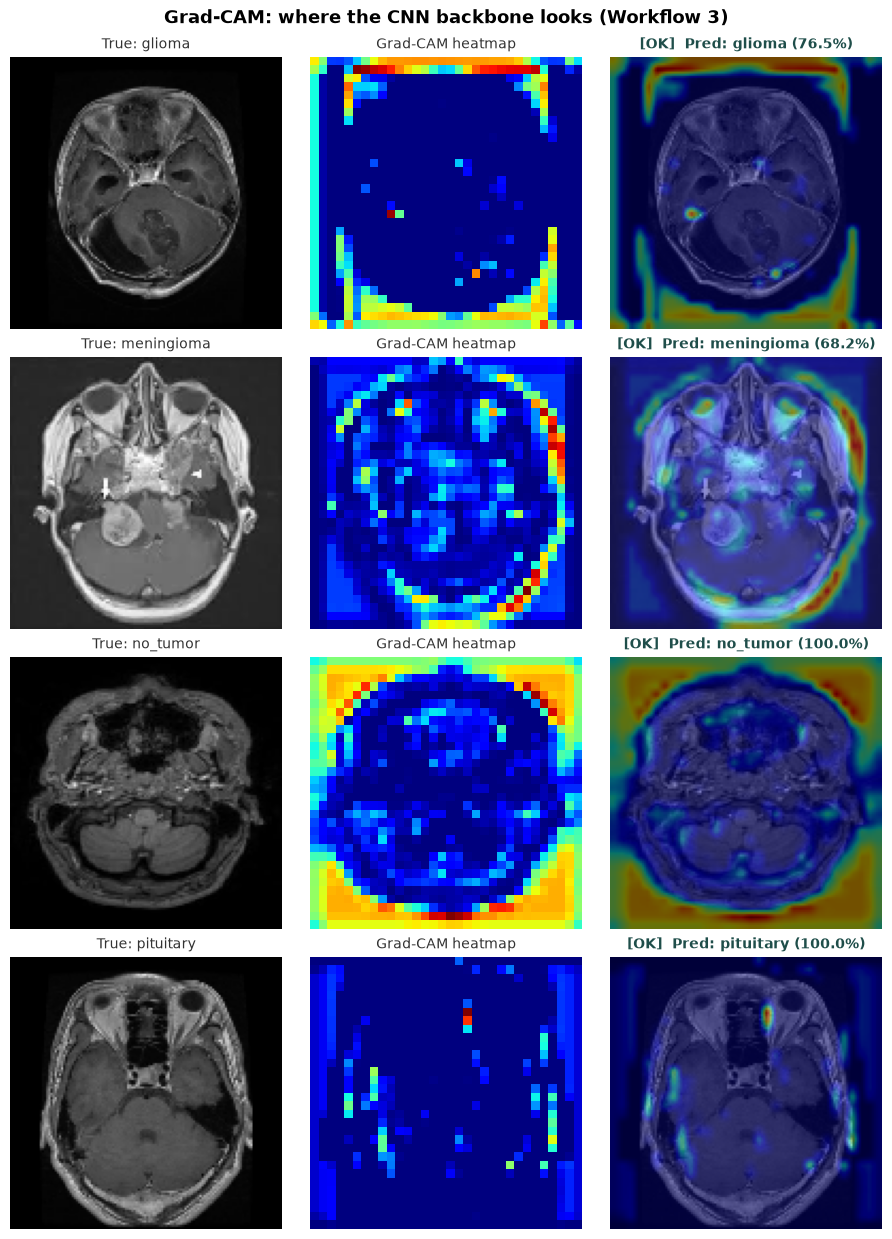


Saved to /mnt/c/Users/cbot/Desktop/BRISC pos graduação/brisc_gui/workflow3_resultados/gradcam/fig_gradcam_grid.[png,pdf]


In [35]:
# 4-row grid: original | heatmap | overlay per class
fig, axes = plt.subplots(len(examples), 3, figsize=(9, 3 * len(examples)),
                          constrained_layout=True)

for row, (true_class, img_path) in enumerate(examples.items()):
    img_pil = load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    img_arr = img_to_array(img_pil) / 255.0
    img_batch = np.expand_dims(img_arr, axis=0)

    preds = cnn.predict(img_batch, verbose=0)
    pred_idx = int(np.argmax(preds[0]))
    pred_class = CLASSES[pred_idx]
    pred_prob  = preds[0, pred_idx] * 100

    heatmap, _ = make_gradcam_heatmap(img_batch, cnn, last_conv_name, pred_index=pred_idx)
    overlay = overlay_heatmap(img_arr, heatmap, alpha=0.45, cmap='jet')

    correct = (true_class == pred_class)
    title_color = '#1F4E4A' if correct else '#C24B4B'
    title_mark  = 'OK' if correct else 'X'

    axes[row, 0].imshow(img_arr)
    axes[row, 0].set_title(f'True: {true_class}', fontsize=10, color='#333')
    axes[row, 1].imshow(heatmap, cmap='jet')
    axes[row, 1].set_title('Grad-CAM heatmap', fontsize=10, color='#333')
    axes[row, 2].imshow(overlay)
    axes[row, 2].set_title(f'[{title_mark}]  Pred: {pred_class} ({pred_prob:.1f}%)',
                            fontsize=10, color=title_color, fontweight='bold')
    for ax in axes[row]:
        ax.axis('off')

plt.suptitle('Grad-CAM: where the CNN backbone looks (Workflow 3)',
              fontsize=13, fontweight='bold', y=1.02)
plt.savefig(f'{GRADCAM_DIR}/fig_gradcam_grid.png', bbox_inches='tight', dpi=180)
plt.savefig(f'{GRADCAM_DIR}/fig_gradcam_grid.pdf', bbox_inches='tight')
plt.show()
print(f'\nSaved to {GRADCAM_DIR}/fig_gradcam_grid.[png,pdf]')

In [36]:
# Individual high-res overlays (one PNG per class, for slides / appendix)
for true_class, img_path in examples.items():
    img_pil = load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    img_arr = img_to_array(img_pil) / 255.0
    img_batch = np.expand_dims(img_arr, axis=0)

    preds = cnn.predict(img_batch, verbose=0)
    pred_idx = int(np.argmax(preds[0]))
    heatmap, _ = make_gradcam_heatmap(img_batch, cnn, last_conv_name, pred_index=pred_idx)
    overlay = overlay_heatmap(img_arr, heatmap, alpha=0.5, cmap='jet')

    fig, ax = plt.subplots(figsize=(4, 4))
    ax.imshow(overlay); ax.axis('off')
    pred_class = CLASSES[pred_idx]
    pred_prob  = preds[0, pred_idx] * 100
    ax.set_title(f'{true_class} -> {pred_class} ({pred_prob:.1f}%)',
                  fontsize=11, fontweight='bold')
    plt.savefig(f'{GRADCAM_DIR}/gradcam_{true_class}.png', bbox_inches='tight', dpi=180)
    plt.close()

print(f'Individual PNGs saved to {GRADCAM_DIR}/')
for f in sorted(os.listdir(GRADCAM_DIR)):
    sz = os.path.getsize(f'{GRADCAM_DIR}/{f}') / 1024
    print(f'  {f}  ({sz:.1f} KB)')

Individual PNGs saved to /mnt/c/Users/cbot/Desktop/BRISC pos graduação/brisc_gui/workflow3_resultados/gradcam/
  fig_gradcam_grid.pdf  (475.2 KB)
  fig_gradcam_grid.png  (374.7 KB)
  gradcam_glioma.png  (45.0 KB)
  gradcam_meningioma.png  (57.8 KB)
  gradcam_no_tumor.png  (53.5 KB)
  gradcam_pituitary.png  (46.1 KB)


In [37]:
def overlay_heatmap(img, heatmap, alpha=0.45, cmap='jet'):
    """Overlay coloured heatmap on the original image (matplotlib 3.11 compatible)."""
    H, W = img.shape[:2]
    heatmap_resized = cv2.resize(heatmap, (W, H))
    cmap_fn = plt.get_cmap(cmap)          # substitui mcm.get_cmap
    heatmap_colored = cmap_fn(heatmap_resized)[..., :3]
    blended = (1 - alpha) * img + alpha * heatmap_colored
    return np.clip(blended, 0, 1)

print('overlay_heatmap redefined with plt.get_cmap')

overlay_heatmap redefined with plt.get_cmap


CNN architecture (last 8 layers):
  conv2d_1             (None, 64, 64, 64)
  max_pooling2d_1      (None, 32, 32, 64)
  conv2d_2             (None, 32, 32, 128)
  max_pooling2d_2      (None, 16, 16, 128)
  flatten              (None, 32768)
  dense                (None, 128)
  dropout              (None, 128)
  dense_1              (None, 4)

All Conv2D layers (candidates for Grad-CAM):
  conv2d          spatial=128x128  filters=32
  conv2d_1        spatial=64x64  filters=64
  conv2d_2        spatial=32x32  filters=128

Glioma test image predictions:
  glioma        76.51%
  meningioma    19.57%
  no_tumor       0.11%
  pituitary      3.81%

Heatmap stats: shape=(32, 32)  min=0.000  max=1.000  mean=0.125


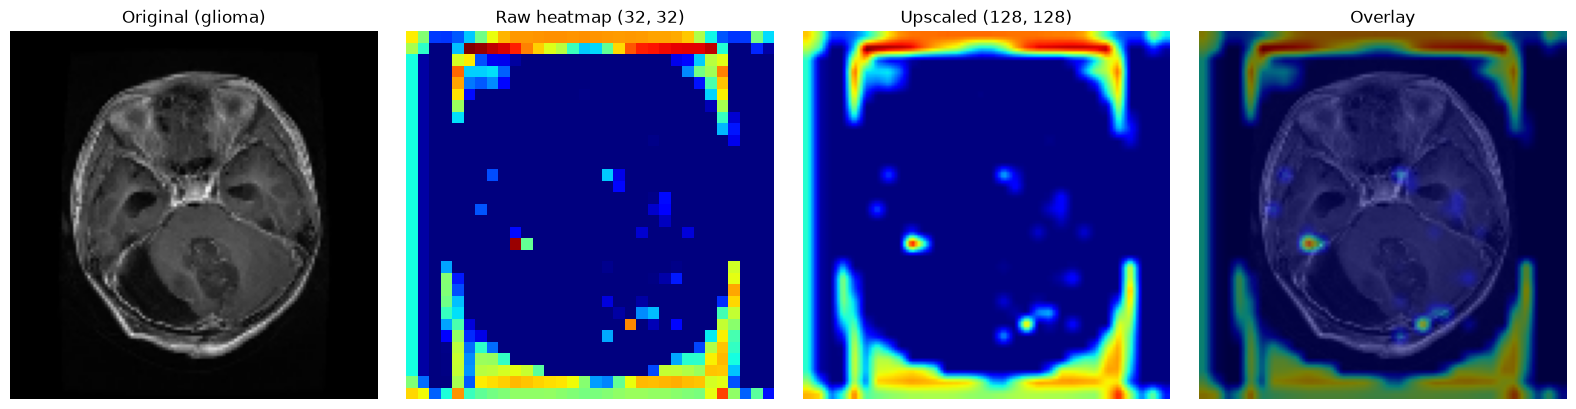

In [38]:
# --- DIAGNOSTIC: which conv layer, prediction confidence, raw heatmap stats ---
print('CNN architecture (last 8 layers):')
for l in cnn.layers[-8:]:
    print(f'  {l.name:20s} {str(l.output.shape)}')

# List available Conv2D layers with resolution
print('\nAll Conv2D layers (candidates for Grad-CAM):')
for l in cnn.layers:
    if 'conv' in l.name.lower():
        h = l.output.shape[1]
        print(f'  {l.name:15s} spatial={h}x{h}  filters={l.output.shape[-1]}')

# Test one glioma image and show what the model actually predicts
img_pil = load_img(examples['glioma'], target_size=(IMG_SIZE, IMG_SIZE))
img_arr = img_to_array(img_pil) / 255.0
img_batch = np.expand_dims(img_arr, axis=0)
preds = cnn.predict(img_batch, verbose=0)[0]
print(f'\nGlioma test image predictions:')
for i, c in enumerate(CLASSES):
    print(f'  {c:12s} {preds[i]*100:6.2f}%')

# Grad-CAM heatmap at last conv layer
hm, pi = make_gradcam_heatmap(img_batch, cnn, last_conv_name)
print(f'\nHeatmap stats: shape={hm.shape}  min={hm.min():.3f}  max={hm.max():.3f}  mean={hm.mean():.3f}')

# Plot: original + raw heatmap + upscaled colored + overlay
fig, ax = plt.subplots(1, 4, figsize=(16, 4))
ax[0].imshow(img_arr); ax[0].set_title(f'Original (glioma)'); ax[0].axis('off')
ax[1].imshow(hm, cmap='jet'); ax[1].set_title(f'Raw heatmap {hm.shape}'); ax[1].axis('off')
hm_up = cv2.resize(hm, (IMG_SIZE, IMG_SIZE))
ax[2].imshow(hm_up, cmap='jet'); ax[2].set_title(f'Upscaled {hm_up.shape}'); ax[2].axis('off')
overlay = overlay_heatmap(img_arr, hm, alpha=0.5)
ax[3].imshow(overlay); ax[3].set_title(f'Overlay'); ax[3].axis('off')
plt.tight_layout(); plt.show()

  glioma       conf 100.00%  brisc2025_test_00033_gl_ax_t1.jpg
  meningioma   conf 100.00%  brisc2025_test_00296_me_ax_t1.jpg
  no_tumor     conf 100.00%  brisc2025_test_00582_no_ax_t1.jpg
  pituitary    conf 100.00%  brisc2025_test_00767_pi_ax_t1.jpg


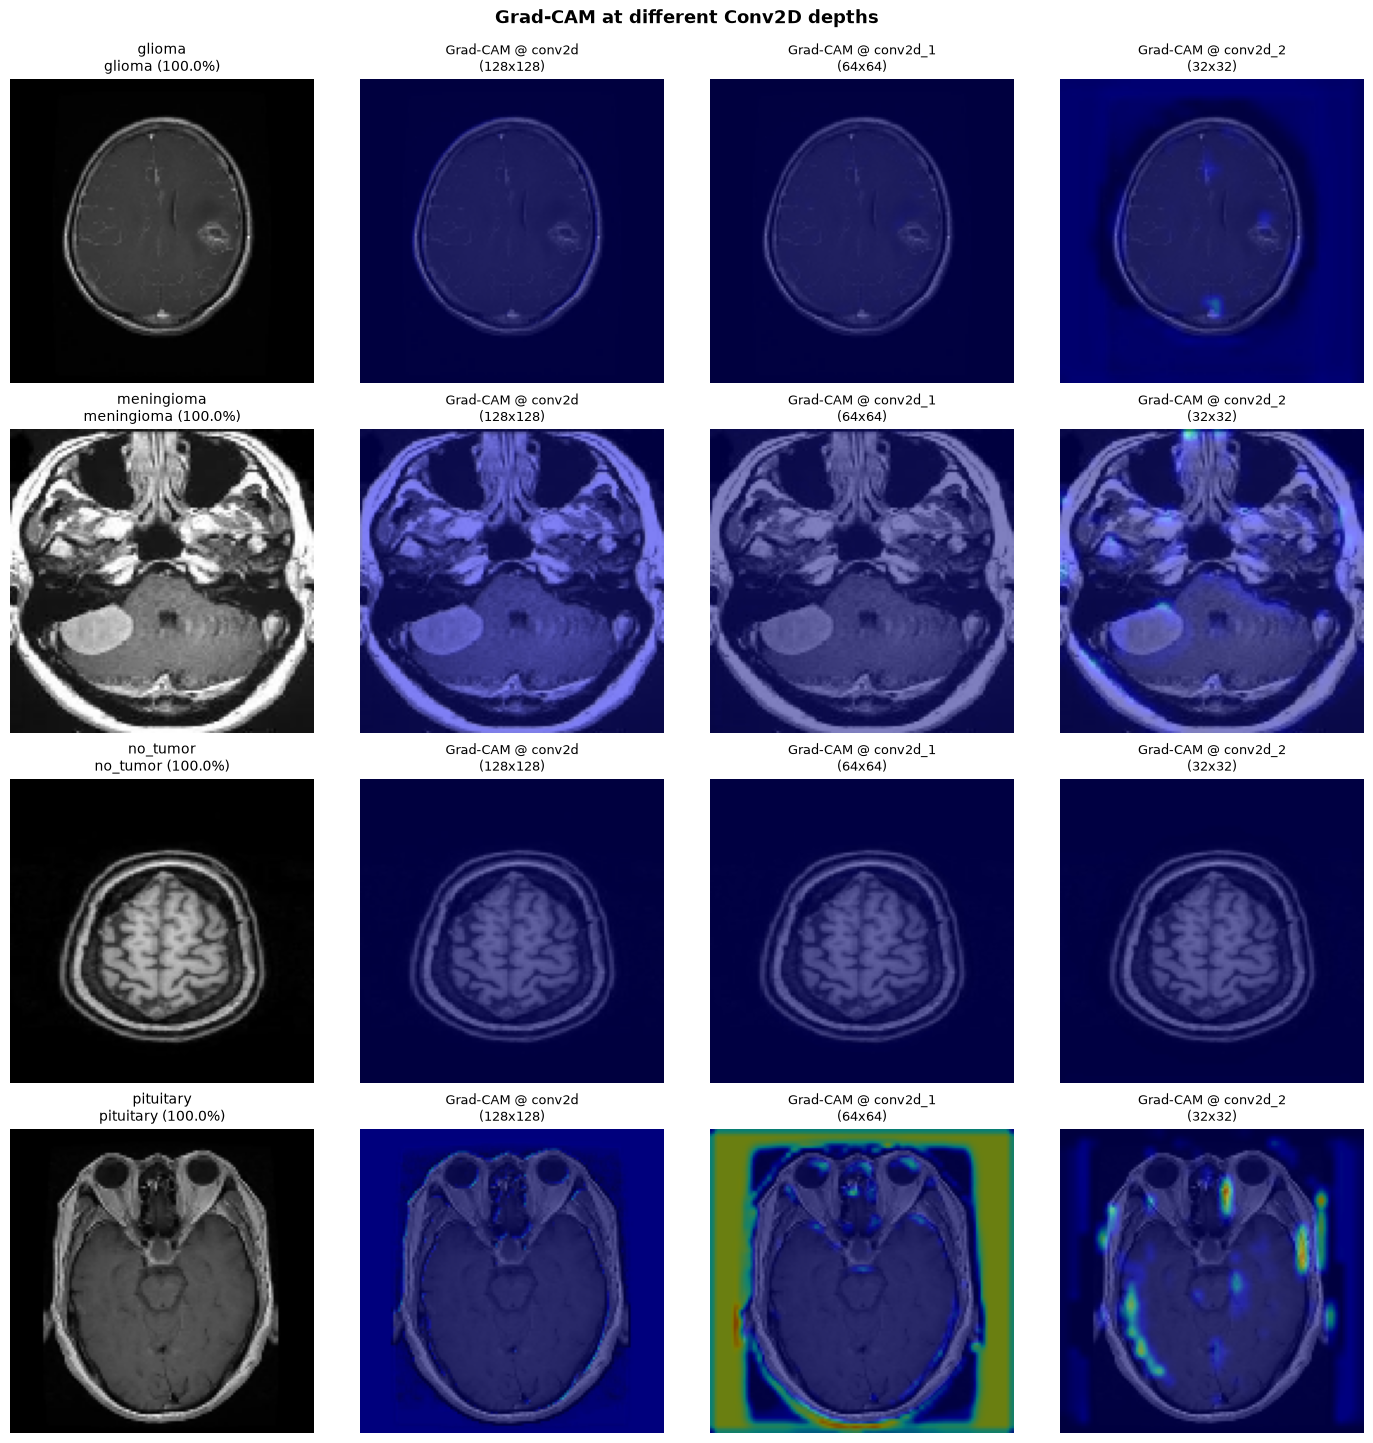

In [39]:
# --- Pick high-confidence examples (>90%) instead of first alphabetical ---
best_examples = {}
for cls in CLASSES:
    cls_dir = os.path.join(TEST_DIR, cls)
    files = sorted(glob.glob(os.path.join(cls_dir, '*')))
    files = [f for f in files if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    best_score = -1; best_path = None
    for p in files[:60]:                                # verifica 60 primeiros por classe
        img = img_to_array(load_img(p, target_size=(IMG_SIZE, IMG_SIZE))) / 255.0
        probs = cnn.predict(np.expand_dims(img, 0), verbose=0)[0]
        pred_idx = int(np.argmax(probs))
        if CLASSES[pred_idx] == cls and probs[pred_idx] > best_score:
            best_score = probs[pred_idx]
            best_path = p
    best_examples[cls] = best_path
    print(f'  {cls:12s} conf {best_score*100:5.2f}%  {os.path.basename(best_path)}')

# --- Compara Grad-CAM em 3 layers diferentes para a glioma escolhida ---
conv_layers = ['conv2d', 'conv2d_1', 'conv2d_2']

fig, axes = plt.subplots(len(CLASSES), 4, figsize=(14, 3.5*len(CLASSES)),
                          constrained_layout=True)
for row, (cls, path) in enumerate(best_examples.items()):
    img = img_to_array(load_img(path, target_size=(IMG_SIZE, IMG_SIZE))) / 255.0
    img_batch = np.expand_dims(img, 0)
    probs = cnn.predict(img_batch, verbose=0)[0]
    pred_idx = int(np.argmax(probs))
    axes[row, 0].imshow(img); axes[row, 0].axis('off')
    axes[row, 0].set_title(f'{cls}\n{CLASSES[pred_idx]} ({probs[pred_idx]*100:.1f}%)', fontsize=10)
    for col, lyr in enumerate(conv_layers, 1):
        hm, _ = make_gradcam_heatmap(img_batch, cnn, lyr, pred_index=pred_idx)
        overlay = overlay_heatmap(img, hm, alpha=0.5, cmap='jet')
        axes[row, col].imshow(overlay); axes[row, col].axis('off')
        axes[row, col].set_title(f'Grad-CAM @ {lyr}\n({hm.shape[0]}x{hm.shape[0]})', fontsize=9)
plt.suptitle('Grad-CAM at different Conv2D depths', fontsize=13, fontweight='bold', y=1.02)
plt.savefig(f'{GRADCAM_DIR}/fig_gradcam_layers_compare.png', bbox_inches='tight', dpi=180)
plt.show()

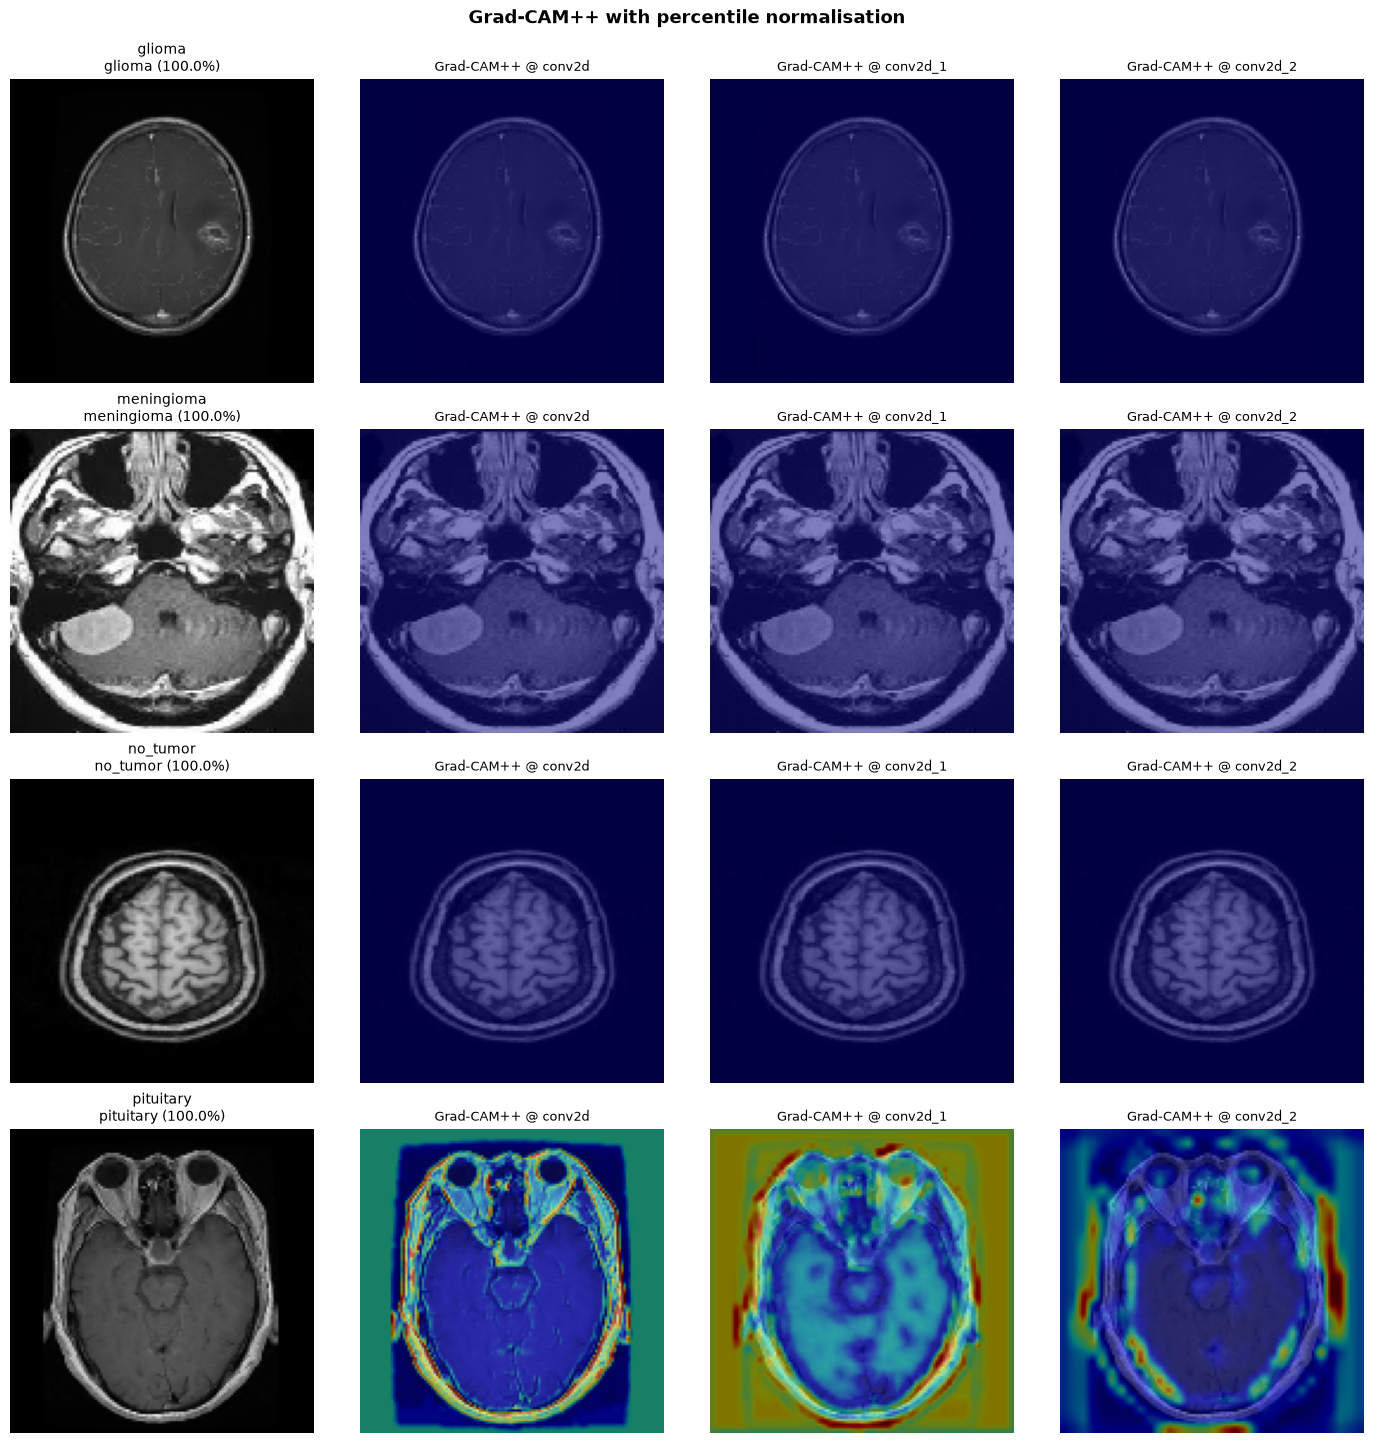

In [40]:
def make_gradcam_heatmap_v2(img_array, model, last_conv_name, pred_index=None, use_pp=True):
    """Grad-CAM++ variant with 99th-percentile normalization for subtler patterns."""
    _ = model(img_array)
    last_conv_layer = model.get_layer(last_conv_name)
    feature_extractor = Model(inputs=model.inputs, outputs=last_conv_layer.output)
    classifier_input = Input(shape=last_conv_layer.output.shape[1:])
    x = classifier_input
    idx = [l.name for l in model.layers].index(last_conv_name)
    for layer in model.layers[idx + 1:]:
        x = layer(x)
    classifier_model = Model(inputs=classifier_input, outputs=x)

    with tf.GradientTape() as tape:
        features = feature_extractor(img_array)
        tape.watch(features)
        preds = classifier_model(features)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    grads = tape.gradient(class_channel, features)
    if use_pp:
        # Grad-CAM++ weight: |grad|^2 / (2|grad|^2 + sum |grad|^3)
        grads_2 = grads ** 2
        grads_3 = grads ** 3
        sum_grads = tf.reduce_sum(features, axis=(1, 2), keepdims=True)
        alpha = grads_2 / (2 * grads_2 + sum_grads * grads_3 + 1e-8)
        weights = tf.reduce_sum(alpha * tf.nn.relu(grads), axis=(1, 2))
    else:
        weights = tf.reduce_mean(grads, axis=(0, 1, 2))
    
    heatmap = tf.reduce_sum(features[0] * weights, axis=-1)
    heatmap = tf.maximum(heatmap, 0)
    hm = heatmap.numpy()
    # Percentile-based normalisation (robust to single-pixel outliers)
    p99 = np.percentile(hm, 99) + 1e-8
    hm = np.clip(hm / p99, 0, 1)
    return hm, int(pred_index.numpy() if hasattr(pred_index, 'numpy') else pred_index)


# Re-run the 4×4 grid with the improved Grad-CAM++
fig, axes = plt.subplots(len(CLASSES), 4, figsize=(14, 3.5*len(CLASSES)),
                          constrained_layout=True)
for row, (cls, path) in enumerate(best_examples.items()):
    img = img_to_array(load_img(path, target_size=(IMG_SIZE, IMG_SIZE))) / 255.0
    img_batch = np.expand_dims(img, 0)
    probs = cnn.predict(img_batch, verbose=0)[0]
    pred_idx = int(np.argmax(probs))
    axes[row, 0].imshow(img); axes[row, 0].axis('off')
    axes[row, 0].set_title(f'{cls}\n{CLASSES[pred_idx]} ({probs[pred_idx]*100:.1f}%)', fontsize=10)
    for col, lyr in enumerate(['conv2d', 'conv2d_1', 'conv2d_2'], 1):
        hm, _ = make_gradcam_heatmap_v2(img_batch, cnn, lyr, pred_index=pred_idx)
        overlay = overlay_heatmap(img, hm, alpha=0.5, cmap='jet')
        axes[row, col].imshow(overlay); axes[row, col].axis('off')
        axes[row, col].set_title(f'Grad-CAM++ @ {lyr}', fontsize=9)
plt.suptitle('Grad-CAM++ with percentile normalisation', fontsize=13, fontweight='bold', y=1.02)
plt.savefig(f'{GRADCAM_DIR}/fig_gradcam_pp.png', bbox_inches='tight', dpi=180)
plt.show()